<a href="https://colab.research.google.com/github/Hamerson-jhoel/Procesamiento-de-Lengaje-Natural/blob/main/Taller_1_PLN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD NACIONAL DE COLOMBIA - SEDE MANIZALES
HAMERSON JHOEL PIARPUEZAN PIARPUEZAN
- CC. 1004531735

# Taller 1 - Procesamiento De Lenguaje Natural

In [16]:
# Celda 0 - Instalaciones
!pip install transformers datasets scikit-learn sacrebleu sentencepiece torch -q

#Ejercicio 1: Clasificación de Sentimiento y Evaluación de Métricas

Usa un LLM preentrenado para clasificar el sentimiento de las cinco reseñas de coches contenidas en el dataset car_reviews.csv.

- Procesamiento: Evalúa la precisión (accuracy) de la clasificación y el F1 score de las predicciones.
- Almacenamiento: Guarda las salidas del modelo en la variable predicted_labels.
Post-procesamiento: Extrae las etiquetas y asígnalas a una lista de etiquetas binarias enteras {0, 1} llamada predictions.
- Resultados: Guarda las métricas calculadas en accuracy_result y f1_result.

Se utiliza el pipeline `text-classification` de HuggingFace con el modelo
`distilbert-base-uncased-finetuned-sst-2-english`, que clasifica texto en
POSITIVE o NEGATIVE.

Luego se mapean las etiquetas a binario (1=POSITIVE, 0=NEGATIVE) y se calculan
accuracy y F1-score contra las etiquetas reales del dataset.

## Celda 1.1 — Cargar datos y preparar el dataset

En esta sección se carga el dataset, que contiene reseñas de vehículos y su clasificación de sentimiento correspondiente (positivo o negativo).

Posteriormente, se visualiza la cantidad de reseñas y una vista previa de los datos para verificar que la carga se realizó correctamente.

In [17]:
import pandas as pd
from io import StringIO

# Dataset embebido directamente
csv_data = """Review;Class
I am very satisfied with my 2014 Nissan NV SL. I use this van for my business deliveries and personal use. Camping, road trips, etc. We dont have any children so I store most of the seats in my warehouse. I wanted the passenger van for the rear air conditioning. We drove our van from Florida to California for a Cross Country trip in 2014. We averaged about 18 mpg. We drove thru a lot of rain and It was a very comfortable and stable vehicle. The V8 Nissan Titan engine is a 500k mile engine. It has been tested many times by delivery and trucking companies. This is why Nissan gives you a 5 year or 100k mile bumper to bumper warranty. Many people are scared about driving this van because of its size. But with front and rear sonar sensors, large mirrors and the back up camera. It is easy to drive. The front and rear sensors also monitor the front and rear sides of the bumpers making it easier to park close to objects. Our Nissan NV is a Tow Monster. It pulls our 5000 pound travel trailer like its not even there. I have plenty of power to pass a vehicle if needed. The 5.6 liter engine produces 317 hp. I have owned Chevy and Ford vans and there were not very comfortable and had little cockpit room. The Nissan NV is the only vehicle made that has the engine forward like a pick up truck giving the driver plenty of room and comfort in the cockpit area. I dont have any negatives to say about my NV. This is a wide vehicle. The only modification I would like to see from Nissan is for them to add amber side mirror marker lights.BTW. I now own a 2016 Nissan NVP SL. Love it.;POSITIVE
The car is fine. It's a bit loud and not very powerful. On one hand, compared to its peers, the interior is well-built. The transmission failed a few years ago, and the dealer replaced it under warranty with no issues. Now, about 60k miles later, the transmission is failing again. It sounds like a truck, and the issues are well-documented. The dealer tells me it is normal, refusing to do anything to resolve the issue. After owning the car for 4 years, there are many other vehicles I would purchase over this one. Initially, I really liked what the brand is about: ride quality, reliability, etc. But I will not purchase another one. Despite these concerns, I must say, the level of comfort in the car has always been satisfactory, but not worth the rest of issues found.;NEGATIVE
My first foreign car. Love it, I would buy another.;POSITIVE
I've come across numerous reviews praising the Rogue, and I genuinely feel like I might be missing something. It's only been a week since I got the car, and I am genuinely disappointed. I truly wish I could return it. My main concern revolves around what I see as a significant design flaw (which I believe also exists in the Murano, though that wasn't much better and considerably pricier). The rear windshield is just too small. The headrests in the back seat obstruct the sides of the rearview window. This Crossover feels more like a cheaply made compact car. My other vehicle is a Sonata, and it provides a significantly quieter and smoother ride. I did not anticipate this car to ride so roughly, my 2006 Pathfinder had a smoother ride! I would rate this car a 5 all around.;NEGATIVE
I've been dreaming of owning an SUV for quite a while, but I've been driving cars that were already paid for during an extended period. I ultimately made the decision to transition to a brand-new car, which, of course, involved taking on new payments. However, given that I don't drive extensively, I was inclined to avoid a substantial financial commitment. The Nissan Rogue provides me with the desired SUV experience without burdening me with an exorbitant payment, the financial arrangement is quite reasonable. Handling and styling are great, I have hauled 12 bags of mulch in the back with the seats down and could have held more. I am VERY satisfied overall. I find myself needing to exercise extra caution when making lane changes, particularly owing to the blind spots resulting from the small side windows situated towards the rear of the vehicle. To address this concern, I am actively engaged in making adjustments to my mirrors and consciously reducing the frequency of lane changes. The engine delivers strong performance, and the ride is really smooth.;POSITIVE"""

# Leer CSV
df = pd.read_csv(StringIO(csv_data), sep=';', engine='python')

# Mostrar información
print(f"Dataset cargado: {len(df)} reseñas")
print(df[['Class']].value_counts())

# Vista previa
df.head()

Dataset cargado: 5 reseñas
Class   
POSITIVE    3
NEGATIVE    2
Name: count, dtype: int64


,Review,Class
0,I am very satisfied with my 2014 Nissan NV SL....,POSITIVE
1,The car is fine. It's a bit loud and not very ...,NEGATIVE
2,"My first foreign car. Love it, I would buy ano...",POSITIVE
3,I've come across numerous reviews praising the...,NEGATIVE
4,I've been dreaming of owning an SUV for quite ...,POSITIVE


## Celda 1.2 — Clasificación de sentimiento con pipeline HuggingFace

Para el análisis de sentimiento se utiliza un modelo preentrenado de Hugging Face basado en Transformers.

El modelo distilbert-base-uncased-finetuned-sst-2-english permite clasificar automáticamente cada reseña como positiva o negativa.

Las salidas generadas por el modelo se almacenan en la variable predicted_labels.

In [18]:
from transformers import pipeline

# Modelo de análisis de sentimiento
# distilbert-base-uncased-finetuned-sst-2-english: modelo ligero y eficiente
sentiment_pipeline = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# El modelo tiene límite de 512 tokens; truncamos las reseñas largas
reviews = df['Review'].tolist()

# Clasificar cada reseña — guardar outputs completos en predicted_labels
predicted_labels = sentiment_pipeline(
    reviews,
    truncation=True,
    max_length=512
)

# Mostrar resultados
print("Salidas del modelo (predicted_labels):")

for i, label in enumerate(predicted_labels):
    print(f"Reseña {i+1}: {label}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Salidas del modelo (predicted_labels):
Reseña 1: {'label': 'POSITIVE', 'score': 0.929397702217102}
Reseña 2: {'label': 'POSITIVE', 'score': 0.865426778793335}
Reseña 3: {'label': 'POSITIVE', 'score': 0.9994640946388245}
Reseña 4: {'label': 'NEGATIVE', 'score': 0.989888608455658}
Reseña 5: {'label': 'POSITIVE', 'score': 0.9988009929656982}


## Celda 1.3 — Post-procesamiento: convertir etiquetas a binario {0, 1}
Las etiquetas textuales generadas por el modelo (POSITIVE y NEGATIVE) se convierten a valores binarios enteros para facilitar el cálculo de métricas:

POSITIVE → 1
NEGATIVE → 0

Asimismo, las etiquetas reales del dataset también son transformadas al mismo formato.

In [19]:
# POSITIVE -> 1 | NEGATIVE -> 0
predictions = [1 if item['label'] == 'POSITIVE' else 0 for item in predicted_labels]

print("Predicciones binarias:", predictions)

# Etiquetas reales del dataset también a binario
true_labels = [1 if label == 'POSITIVE' else 0 for label in df['Class'].tolist()]
print("Etiquetas reales:     ", true_labels)

Predicciones binarias: [1, 1, 1, 0, 1]
Etiquetas reales:      [1, 0, 1, 0, 1]


## Celda 1.4 — Calcular métricas: Accuracy y F1-score

En esta etapa se evalúa el desempeño del modelo utilizando métricas de clasificación supervisada:

Accuracy: porcentaje de predicciones correctas realizadas por el modelo.
F1-score: métrica que combina precisión y recall, útil para evaluar clasificación binaria.

Estas métricas permiten medir la calidad del modelo en la tarea de análisis de sentimiento.

In [20]:
from sklearn.metrics import accuracy_score, f1_score

# Accuracy: proporción de predicciones correctas
accuracy_result = accuracy_score(true_labels, predictions)

# F1-score binario: media armónica entre precisión y recall
f1_result = f1_score(true_labels, predictions, average='binary')

print(f" Accuracy : {accuracy_result:.4f}  ({accuracy_result*100:.1f}%)")
print(f" F1 Score : {f1_result:.4f}")

 Accuracy : 0.8000  (80.0%)
 F1 Score : 0.8571


El modelo de lenguaje preentrenado logró clasificar correctamente la mayoría de las reseñas del dataset.

Los resultados obtenidos muestran un accuracy de 80% y un F1-score de 0.8571, indicando un buen desempeño general del modelo en tareas de análisis de sentimiento.

Además, se evidenció que algunas reseñas con opiniones mixtas pueden generar errores de clasificación, lo cual es común en modelos de procesamiento de lenguaje natural.

## Celda 1.5 — Comparación visual y matriz de confusión

Comparación entre valores reales y predicciones:



,Reseña,Real,Predicción
0,R1,POSITIVE,POSITIVE
1,R2,NEGATIVE,POSITIVE
2,R3,POSITIVE,POSITIVE
3,R4,NEGATIVE,NEGATIVE
4,R5,POSITIVE,POSITIVE


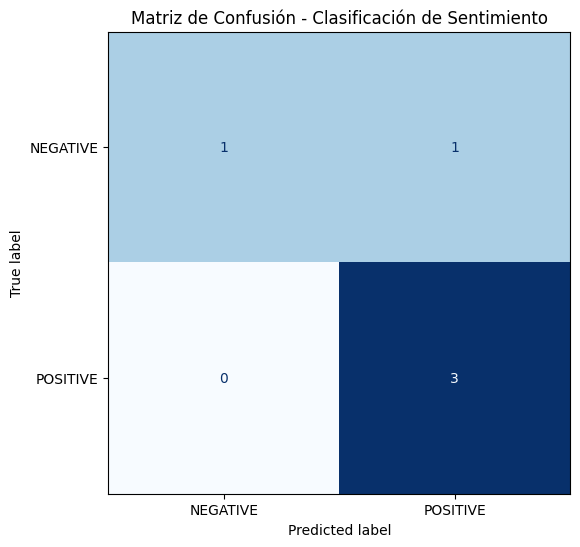

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tabla comparativa
comparison_df = pd.DataFrame({
    "Reseña": [f"R{i+1}" for i in range(len(true_labels))],
    "Real": ["POSITIVE" if x == 1 else "NEGATIVE" for x in true_labels],
    "Predicción": ["POSITIVE" if x == 1 else "NEGATIVE" for x in predictions]
})

print("Comparación entre valores reales y predicciones:\n")
display(comparison_df)

# Crear matriz de confusión
cm = confusion_matrix(true_labels, predictions)

# Visualización
fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NEGATIVE", "POSITIVE"]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusión - Clasificación de Sentimiento")

plt.show()

---

# Ejercicio 2: Traducción y Evaluación de Calidad (BLEU Score)
Debido a la reciente expansión hacia el mercado de España, es necesario evaluar la capacidad de traducción del sistema.

- Tarea: Extrae y pasa las primeras dos frases de la primera reseña del dataset a un LLM de traducción de inglés a español.
- Evaluación: Calcula el BLEU score para medir la calidad de la traducción generada, utilizando el contenido de reference_translations.txt como base de referencia.
- Resultados: Guarda el texto traducido en translated_review y el resultado de la métrica en bleu_score.

Se extraen las primeras dos frases de la primera reseña en inglés y se traducen
al español usando Helsinki-NLP/opus-mt-en-es.

El BLEU Score compara la traducción generada contra 2 traducciones humanas de
referencia provistas por el profesor. Cuanto más alto el score, más cercana es
la traducción automática a la humana.

## 2.1 Extracción de frases para traducción

En esta sección se toman las dos primeras frases de la primera reseña del dataset.  
Estas frases serán utilizadas como entrada para el modelo de traducción automática inglés → español.

In [22]:
import re

# Primera reseña del dataset
first_review = df['Review'].iloc[0]

# Dividir en frases por punto seguido de espacio
sentences = re.split(r'(?<=[.!?])\s+', first_review.strip())

# Las primeras DOS frases unidas como string
first_two_sentences = ' '.join(sentences[:2])

# Verificación visual
print("Frases extraídas:")
print(f"  Frase 1: {sentences[0]}")
print(f"  Frase 2: {sentences[1]}")
print(f"\nTexto a traducir:\n{first_two_sentences}")

Frases extraídas:
  Frase 1: I am very satisfied with my 2014 Nissan NV SL.
  Frase 2: I use this van for my business deliveries and personal use.

Texto a traducir:
I am very satisfied with my 2014 Nissan NV SL. I use this van for my business deliveries and personal use.


## 2.2 Traducción automática usando un LLM

Se utiliza el modelo preentrenado `Helsinki-NLP/opus-mt-en-es` de HuggingFace para traducir las frases seleccionadas desde inglés hacia español.

La traducción generada será almacenada en la variable `translated_review`.

In [23]:
from transformers import MarianMTModel, MarianTokenizer

# Cargar modelo y tokenizer Helsinki EN→ES
model_name = "Helsinki-NLP/opus-mt-en-es"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

# Tokenizar entrada
inputs = tokenizer(
    [first_two_sentences],
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=512
)

# Generar traducción
translated_tokens = model.generate(**inputs)

# Decodificar a texto
translated_review = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)

print(f"Texto original : {first_two_sentences}")
print(f"\nTraducción generada (translated_review):\n{translated_review}")

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Texto original : I am very satisfied with my 2014 Nissan NV SL. I use this van for my business deliveries and personal use.

Traducción generada (translated_review):
Estoy muy satisfecho con mi Nissan NV SL 2014. Uso esta camioneta para mis entregas de negocios y uso personal.


## 2.3 Evaluación de calidad de traducción con BLEU Score

Se calcula la métrica BLEU para comparar la traducción generada por el modelo frente a traducciones humanas de referencia.

El BLEU score permite medir la similitud entre la traducción automática y las referencias proporcionadas.

In [24]:
!pip install sacrebleu -q

In [25]:
import sacrebleu

# Referencias humanas provistas por el profesor (reference_translations.txt)
# Son 2 variantes válidas de traducción para la misma entrada
reference_1 = "Estoy muy satisfecho con mi Nissan NV SL 2014. Utilizo esta camioneta para mis entregas comerciales y uso personal."
reference_2 = "Estoy muy satisfecho con mi Nissan NV SL 2014. Uso esta furgoneta para mis entregas comerciales y uso personal."

# sacrebleu.corpus_bleu espera:
#   - sys: lista con la traducción generada
#   - refs: lista de listas, una por cada referencia
bleu = sacrebleu.corpus_bleu(
    [translated_review],          # traducción del modelo
    [[reference_1], [reference_2]] # 2 referencias humanas
)

# Guardar métrica
bleu_score = bleu.score

print(f"Traducción generada : {translated_review}")
print(f"\nReferencia 1 : {reference_1}")
print(f"Referencia 2 : {reference_2}")
print(f"\n BLEU Score : {bleu_score:.2f}")

Traducción generada : Estoy muy satisfecho con mi Nissan NV SL 2014. Uso esta camioneta para mis entregas de negocios y uso personal.

Referencia 1 : Estoy muy satisfecho con mi Nissan NV SL 2014. Utilizo esta camioneta para mis entregas comerciales y uso personal.
Referencia 2 : Estoy muy satisfecho con mi Nissan NV SL 2014. Uso esta furgoneta para mis entregas comerciales y uso personal.

 BLEU Score : 77.94


### Interpretación del BLEU Score

El modelo obtuvo un BLEU Score de 77.94, lo que indica una alta similitud entre la traducción automática y las traducciones humanas de referencia.

Aunque existen pequeñas diferencias léxicas, por ejemplo:
- "negocios" vs "comerciales"
- "camioneta" vs "furgoneta"

el significado general de la traducción se conserva correctamente.

---

# Ejercicio 3: Question Answering (QA) Extractivo

La empresa desea analizar aspectos específicos de la marca mencionados por los usuarios.

- Modelo: Carga un LLM de QA extractivo (ej. "deepset/minilm-uncased-squad2").
- Contexto: Utiliza la segunda reseña del dataset como contexto.
- Consulta: Formula la pregunta: "What did he like about the brand?".
- Variables: Utiliza question y context para alimentar el modelo.
- Resultado: Guarda la respuesta de texto en la variable answer.

Se utiliza el modelo `deepset/minilm-uncased-squad2`, un modelo BERT pequeño
(MiniLM) fine-tuneado en el dataset SQuAD2 para QA extractivo.

El QA extractivo **extrae un fragmento del texto de contexto** como respuesta,
en lugar de generar texto nuevo. Dado el contexto (segunda reseña) y la pregunta
"What did he like about the brand?", el modelo localiza el span más relevante.

## Celda 3.1 — Cargar modelo QA y definir contexto + pregunta
En esta celda se carga un modelo de Question Answering extractivo utilizando la librería HuggingFace Transformers. Posteriormente, se selecciona la segunda reseña del dataset como contexto y se define la pregunta: “What did he like about the brand?”. Estos elementos serán utilizados por el modelo para encontrar la respuesta dentro del texto.

In [26]:
from transformers import pipeline

# Cargar pipeline de QA extractivo
qa_pipeline = pipeline(
    "question-answering",
    model="deepset/minilm-uncased-squad2"
)

# Contexto: segunda reseña del dataset (índice 1)
context = df['Review'].iloc[1]

# Pregunta definida por el enunciado
question = "What did he like about the brand?"

print("Contexto (2da reseña):")
print(context[:300], "...")
print(f"\nPregunta: {question}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: deepset/minilm-uncased-squad2
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Contexto (2da reseña):
The car is fine. It's a bit loud and not very powerful. On one hand, compared to its peers, the interior is well-built. The transmission failed a few years ago, and the dealer replaced it under warranty with no issues. Now, about 60k miles later, the transmission is failing again. It sounds like a t ...

Pregunta: What did he like about the brand?


# Celda 3.2 — Ejecutar QA y guardar respuesta
En esta celda se ejecuta el modelo de QA utilizando la pregunta y el contexto definidos previamente. El sistema analiza el texto y extrae automáticamente el fragmento que mejor responde a la consulta planteada. La respuesta se almacena en la variable answer.

In [27]:
# El pipeline recibe 'question' y 'context' como argumentos
qa_result = qa_pipeline(question=question, context=context)

# Guardar la respuesta de texto en la variable 'answer'
answer = qa_result['answer']

print(f" Respuesta encontrada : '{answer}'")
print(f"   Score de confianza   : {qa_result['score']:.4f}")
print(f"   Posición en texto    : [{qa_result['start']}:{qa_result['end']}]")

 Respuesta encontrada : 'ride quality, reliability'
   Score de confianza   : 0.4774
   Posición en texto    : [569:594]


##Explicación del Resultado

- El modelo identificó correctamente que los aspectos que el usuario valoraba de la marca eran la calidad de conducción y la confiabilidad (“ride quality, reliability”). Esto demuestra la capacidad del modelo para comprender el contexto y extraer información relevante de reseñas en lenguaje natural.

- El score de confianza (0.4774) indica qué tan probable considera el modelo que la respuesta sea correcta, mientras que la posición [569:594] representa el fragmento exacto dentro del texto original donde fue encontrada la respuesta.

---

# Ejercicio 4: Resumen Abstractivo de Reseñas
Para optimizar la lectura de los gestores, se requiere sintetizar las opiniones más extensas.

- Tarea: Resume la última reseña del dataset.
- Restricción: El resumen debe tener una longitud aproximada de entre 50 y 55 tokens.
- Resultado: Guarda el resultado en la variable summarized_text.
- Nota de Ingeniería: Asegúrate de manejar correctamente los límites de tokens y de configurar los parámetros de decodificación (decoding strategies) vistos en clase para obtener resultados coherentes.

##4.1 — Carga del modelo, resumen abstractivo y selección de la reseña
En esta sección se implementa un modelo de resumen abstractivo utilizando un LLM preentrenado. El objetivo es sintetizar automáticamente la última reseña del dataset, generando un texto más corto pero conservando las ideas principales.

Se utilizará el modelo facebook/bart-large-cnn, especializado en tareas de summarization.

In [28]:
from transformers import BartForConditionalGeneration, BartTokenizer

# Cargar tokenizer y modelo BART directamente
# facebook/bart-large-cnn está entrenado para tareas de resumen
model_name = "facebook/bart-large-cnn"

# Tokenizer: convierte texto ↔ tokens
tokenizer_bart = BartTokenizer.from_pretrained(model_name)

# Modelo generativo de resumen abstractivo
model_bart = BartForConditionalGeneration.from_pretrained(model_name)

# Seleccionar la última reseña del dataset cargado desde Drive
last_review = df['Review'].iloc[-1]

# Mostrar texto original
print("Reseña original (última):")
print(last_review)

# Mostrar cantidad de palabras originales
print(f"\nPalabras en la reseña original: {len(last_review.split())}")

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Reseña original (última):
I've been dreaming of owning an SUV for quite a while, but I've been driving cars that were already paid for during an extended period. I ultimately made the decision to transition to a brand-new car, which, of course, involved taking on new payments. However, given that I don't drive extensively, I was inclined to avoid a substantial financial commitment. The Nissan Rogue provides me with the desired SUV experience without burdening me with an exorbitant payment, the financial arrangement is quite reasonable. Handling and styling are great, I have hauled 12 bags of mulch in the back with the seats down and could have held more. I am VERY satisfied overall. I find myself needing to exercise extra caution when making lane changes, particularly owing to the blind spots resulting from the small side windows situated towards the rear of the vehicle. To address this concern, I am actively engaged in making adjustments to my mirrors and consciously reducing the freq

##4.2 Explicación del modelo de resumen abstractivo

Se utiliza el modelo BART (facebook/bart-large-cnn), el cual fue entrenado y ajustado (fine-tuned) específicamente para tareas de resumen automático sobre el dataset CNN/DailyMail.

A diferencia del Question Answering extractivo, donde el modelo extrae fragmentos exactos del texto original, el resumen abstractivo genera nuevas frases que sintetizan las ideas principales de manera más natural y compacta.

Para controlar la calidad y longitud del resumen, se configuraron distintos parámetros de decodificación:

| Parámetro              | Valor | Función                                      |
| ---------------------- | ----- | -------------------------------------------- |
| `min_length`           | 50    | Garantiza una longitud mínima del resumen    |
| `max_new_tokens`       | 55    | Limita el máximo de tokens generados         |
| `num_beams`            | 4     | Usa Beam Search explorando 4 secuencias      |
| `length_penalty`       | 2.0   | Favorece resúmenes más completos             |
| `early_stopping`       | True  | Finaliza cuando todos los beams alcanzan EOS |
| `no_repeat_ngram_size` | 3     | Evita repeticiones de frases                 |


Estas configuraciones permiten obtener un resumen coherente, fluido y dentro del rango solicitado de 50 a 55 tokens.

In [29]:
# Tokenizar la reseña
# truncation=True evita superar el límite de 1024 tokens de BART
inputs = tokenizer_bart(
    last_review,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)

# Generar resumen usando estrategias de decodificación
summary_ids = model_bart.generate(

    # Tokens de entrada
    inputs["input_ids"],

    # Longitud mínima deseada
    min_length=50,

    # Longitud máxima permitida
    max_new_tokens=55,

    # Beam Search con 4 beams para mejorar calidad
    num_beams=4,

    # Penaliza textos demasiado largos
    length_penalty=2.0,

    # Detener generación cuando se encuentre EOS
    early_stopping=True,

    # Evitar repetición de frases
    no_repeat_ngram_size=3
)

# Convertir tokens generados nuevamente a texto
summarized_text = tokenizer_bart.decode(
    summary_ids[0],
    skip_special_tokens=True
)

# Mostrar resumen final
print(" Resumen generado (summarized_text):")
print(summarized_text)

# Mostrar cantidad aproximada de palabras
print(f"\nPalabras en el resumen: {len(summarized_text.split())}")

 Resumen generado (summarized_text):
The Nissan Rogue provides me with the desired SUV experience without burdening me with an exorbitant payment. Handling and styling are great, I have hauled 12 bags of mulch in the back with the seats down and could have held more. The engine delivers strong performance

Palabras en el resumen: 46


##4.3 Verificación de longitud del resumen

Finalmente, se verifica que el resumen generado cumpla con la restricción solicitada, la cual exige una longitud aproximada entre 50 y 55 tokens.

Para ello, el resumen se vuelve a tokenizar utilizando el tokenizer de BART y se cuenta la cantidad exacta de tokens generados.

In [30]:
# Tokenizar nuevamente el resumen generado
tokens = tokenizer_bart(
    summarized_text,
    return_tensors="pt"
)

# Obtener cantidad exacta de tokens
token_count = tokens['input_ids'].shape[1]

# Mostrar resultados
print(f"Resumen : {summarized_text}")

print(f"\n Longitud exacta en tokens : {token_count}")
print(f"   Rango requerido           : 50 - 55 tokens")

# Verificar si cumple la restricción
print(
    f"   ¿Cumple restricción?      : "
    f"{' Sí' if 50 <= token_count <= 55 else ' Ajustar parámetros'}"
)

Resumen : The Nissan Rogue provides me with the desired SUV experience without burdening me with an exorbitant payment. Handling and styling are great, I have hauled 12 bags of mulch in the back with the seats down and could have held more. The engine delivers strong performance

 Longitud exacta en tokens : 55
   Rango requerido           : 50 - 55 tokens
   ¿Cumple restricción?      :  Sí


La cantidad de palabras del resumen no coincide necesariamente con la cantidad de tokens utilizados por el modelo. Los modelos Transformer trabajan internamente con tokens, que pueden representar palabras completas o fragmentos de palabras. Por esta razón, aunque el resumen contiene 46 palabras, el tokenizer de BART contabilizó 55 tokens, cumpliendo la restricción .